In [3]:
!pip install optuna tqdm scikit-learn


In [4]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics import f1_score, classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
import nltk
import optuna
from tqdm import tqdm

nltk.download("stopwords")
spanish_stopwords = stopwords.words("spanish")



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [5]:
# ============================
# 1. Cargar dataset
# ============================
train_df = pd.read_csv("train_final.csv")
test_df = pd.read_csv("test_final.csv")

X_train_raw = train_df["Headline_Text"].astype(str).tolist()
X_test_raw = test_df["Headline_Text"].astype(str).tolist()
y_train = train_df["Category"].astype(int).values
y_test = test_df["Category"].astype(int).values



In [6]:
# ============================
# 2. Vectorizadores TF-IDF y Count
# ============================
tfidf = TfidfVectorizer(max_features=5000, stop_words=spanish_stopwords)
count_vec = CountVectorizer(max_features=5000, stop_words=spanish_stopwords)

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_test_tfidf = tfidf.transform(X_test_raw)

X_train_count = count_vec.fit_transform(X_train_raw)
X_test_count = count_vec.transform(X_test_raw)

vocab = tfidf.vocabulary_
max_len = 128



In [7]:
# ============================
# 3. Construcción de secuencias [seq_len, 2]
# ============================
def build_sequence(text, tfidf_vector, count_vector):
    tokens = text.lower().split()
    seq = np.zeros((max_len, 2), dtype=np.float32)
    for i, token in enumerate(tokens[:max_len]):
        if token in vocab:
            col_idx = vocab[token]
            seq[i,0] = tfidf_vector[0, col_idx]
            seq[i,1] = count_vector[0, col_idx]
    return seq

X_train_seq = np.array([build_sequence(text, X_train_tfidf[i], X_train_count[i]) for i,text in enumerate(X_train_raw)])
X_test_seq = np.array([build_sequence(text, X_test_tfidf[i], X_test_count[i]) for i,text in enumerate(X_test_raw)])

X_train_tensor = torch.tensor(X_train_seq, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_seq, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

class SeqDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = SeqDataset(X_train_tensor, y_train_tensor)
test_dataset = SeqDataset(X_test_tensor, y_test_tensor)



In [8]:
# ============================
# 4. Modelo BiGRU + Atención
# ============================
class BiGRU_TFIDF_Attn(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(BiGRU_TFIDF_Attn, self).__init__()
        self.bigru = nn.GRU(input_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.attn = nn.Linear(hidden_dim*2, 1)
        self.fc = nn.Linear(hidden_dim*2, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        gru_out, _ = self.bigru(x)
        weights = torch.softmax(self.attn(gru_out), dim=1)
        context = torch.sum(weights * gru_out, dim=1)
        out = self.dropout(context)
        return self.fc(out)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [9]:
# ============================
# 5. Optuna para optimización
# ============================
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    hidden_dim = trial.suggest_categorical("hidden_dim", [64, 128, 256])
    batch_size = trial.suggest_categorical("batch_size", [32, 64])

    model = BiGRU_TFIDF_Attn(input_dim=2, hidden_dim=hidden_dim, num_classes=2).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    class_counts = torch.bincount(y_train_tensor)
    total = class_counts.sum().float()
    weights = total / class_counts.float()
    weights = weights / weights.sum()
    criterion = nn.CrossEntropyLoss(weight=weights.to(device))

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    for epoch in range(3):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs_val = model(X_val)
            preds = torch.argmax(outputs_val, dim=1)
            y_true.extend(y_val.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    return f1_score(y_true, y_pred, average="macro")

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=10, n_jobs=1)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor F1 macro:", study.best_value)

best_params = study.best_params



[I 2026-06-21 00:30:40,601] A new study created in memory with name: no-name-b6bfb5f6-836f-4374-931e-5b8f5fb7936a
[I 2026-06-21 00:32:10,218] Trial 0 finished with value: 0.6829974094901119 and parameters: {'lr': 0.0001828632899224831, 'hidden_dim': 256, 'batch_size': 64}. Best is trial 0 with value: 0.6829974094901119.
[I 2026-06-21 00:33:49,471] Trial 1 finished with value: 0.7151753280450737 and parameters: {'lr': 0.0010152535229593352, 'hidden_dim': 256, 'batch_size': 32}. Best is trial 1 with value: 0.7151753280450737.
[I 2026-06-21 00:35:28,843] Trial 2 finished with value: 0.6982414242292662 and parameters: {'lr': 0.001502378764731478, 'hidden_dim': 256, 'batch_size': 32}. Best is trial 1 with value: 0.7151753280450737.
[I 2026-06-21 00:35:47,026] Trial 3 finished with value: 0.7176669976674637 and parameters: {'lr': 0.00424469506673152, 'hidden_dim': 64, 'batch_size': 64}. Best is trial 3 with value: 0.7176669976674637.
[I 2026-06-21 00:37:26,879] Trial 4 finished with value: 0

Mejores hiperparámetros: {'lr': 0.00424469506673152, 'hidden_dim': 64, 'batch_size': 64}
Mejor F1 macro: 0.7176669976674637


In [10]:
# ============================
# 6. Entrenamiento final con mejores parámetros
# ============================
model = BiGRU_TFIDF_Attn(input_dim=2, hidden_dim=best_params["hidden_dim"], num_classes=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=best_params["lr"])
train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_params["batch_size"])

class_counts = torch.bincount(y_train_tensor)
total = class_counts.sum().float()
weights = total / class_counts.float()
weights = weights / weights.sum()
criterion = nn.CrossEntropyLoss(weight=weights.to(device))

best_val_f1 = 0
patience = 3
epochs_no_improve = 0
max_epochs = 15

for epoch in range(max_epochs):
    model.train()
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for X_val, y_val in test_loader:
            X_val, y_val = X_val.to(device), y_val.to(device)
            outputs_val = model(X_val)
            preds = torch.argmax(outputs_val, dim=1)
            y_true.extend(y_val.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())
    val_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"Epoch {epoch+1}: Val F1={val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_bigru_tfidf_attn.pt")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping activado")
            break



Epoch 1: Val F1=0.6723
Epoch 2: Val F1=0.6576
Epoch 3: Val F1=0.6834
Epoch 4: Val F1=0.7160
Epoch 5: Val F1=0.7283
Epoch 6: Val F1=0.6896
Epoch 7: Val F1=0.7093
Epoch 8: Val F1=0.7277
Early stopping activado



Evaluación con umbral 0.5
Matriz de confusión:
 [[475  78]
 [ 44  81]]
Exactitud (Accuracy): 0.8200589970501475

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9152    0.8590    0.8862       553
        True     0.5094    0.6480    0.5704       125

    accuracy                         0.8201       678
   macro avg     0.7123    0.7535    0.7283       678
weighted avg     0.8404    0.8201    0.8280       678

ROC-AUC: 0.8772

Umbral óptimo según F1: 0.18570074439048767

Evaluación con umbral ajustado
Matriz de confusión:
 [[412 141]
 [  8 117]]
Exactitud (Accuracy): 0.7802359882005899

Reporte de clasificación:

              precision    recall  f1-score   support

       False     0.9810    0.7450    0.8469       553
        True     0.4535    0.9360    0.6110       125

    accuracy                         0.7802       678
   macro avg     0.7172    0.8405    0.7289       678
weighted avg     0.8837    0.7802    0.8034       678

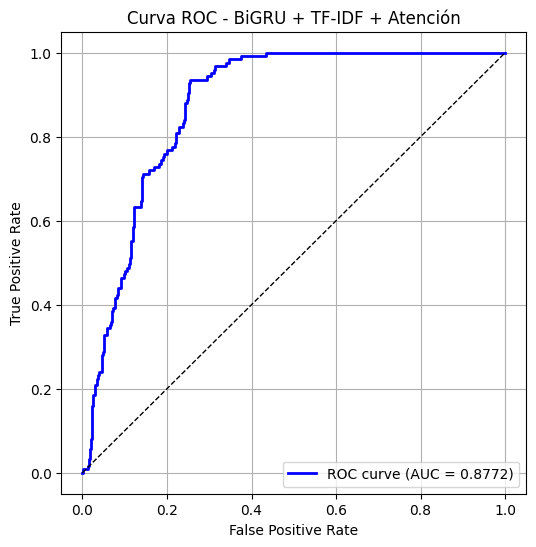

In [11]:
# ============================
# 7. Evaluación final con umbral
# ============================
model.load_state_dict(torch.load("best_bigru_tfidf_attn.pt"))
model.eval()

y_true, y_probs = [], []
with torch.no_grad():
    for X_val, y_val in test_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)
        outputs_val = model(X_val)
        probs = torch.softmax(outputs_val, dim=1)[:,1]
        y_true.extend(y_val.cpu().tolist())
        y_probs.extend(probs.cpu().tolist())

y_true = np.array(y_true)
y_probs = np.array(y_probs)

# --- Evaluación inicial (umbral estándar 0.5) ---
print("\nEvaluación con umbral 0.5")
y_pred_default = (y_probs >= 0.5).astype(int)
cm_def = confusion_matrix(y_true, y_pred_default)
print("Matriz de confusión:\n", cm_def)
print("Exactitud (Accuracy):", accuracy_score(y_true, y_pred_default))
print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred_default, target_names=["False","True"], digits=4))
roc_auc = roc_auc_score(y_true, y_probs)
print(f"ROC-AUC: {roc_auc:.4f}")

# --- Búsqueda de umbral óptimo según F1 ---
precisions, recalls, thresholds = precision_recall_curve(y_true, y_probs)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]
print("\nUmbral óptimo según F1:", best_thr)

# --- Evaluación con umbral ajustado ---
print("\nEvaluación con umbral ajustado")
y_pred_opt = (y_probs >= best_thr).astype(int)
cm_opt = confusion_matrix(y_true, y_pred_opt)
print("Matriz de confusión:\n", cm_opt)
print("Exactitud (Accuracy):", accuracy_score(y_true, y_pred_opt))
print("\nReporte de clasificación:\n")
print(classification_report(y_true, y_pred_opt, target_names=["False","True"], digits=4))
print(f"ROC-AUC: {roc_auc:.4f}")

# --- Curva ROC ---
fpr, tpr, _ = roc_curve(y_true, y_probs)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="blue", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0,1],[0,1], color="black", lw=1, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curva ROC - BiGRU + TF-IDF + Atención")
plt.legend(loc="lower right")
plt.grid(True)
plt.savefig("curva_roc_bigru_tfidf_attn.png", dpi=300, bbox_inches="tight")
plt.show()
